<a href="https://www.kaggle.com/code/lalit7881/9000-popular-people-in-cinema-eda-93?scriptVersionId=322190841" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aminasalamt/9000-popular-people-in-cinema/popular_people.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/aminasalamt/9000-popular-people-in-cinema/popular_people.csv")

In [3]:
df.head()

,name,gender,known_for_department,original_name,popularity
0,Eric Larson,2,Visual Effects,Eric Larson,47.9780
1,Robert Middlemass,2,Acting,Robert Middlemass,47.8017
2,María Vaner,1,Acting,María Vaner,47.2016
3,Carl Wharton,2,Acting,Carl Wharton,36.3365
4,Victor Moore,2,Acting,Victor Moore,35.9181


In [4]:
df.tail()

,name,gender,known_for_department,original_name,popularity
9975,Tamu Blackwell,1,Acting,Tamu Blackwell,1.0432
9976,Yoshio Urasawa,2,Writing,浦沢義雄,1.1777
9977,Miko Hughes,2,Acting,Miko Hughes,1.5346
9978,Phoebe Fox,1,Acting,Phoebe Fox,1.1656
9979,Debora Calì,1,Acting,Debora Calì,1.2658


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9980 entries, 0 to 9979
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  9980 non-null   object 
 1   gender                9980 non-null   int64  
 2   known_for_department  9975 non-null   object 
 3   original_name         9980 non-null   object 
 4   popularity            9980 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 390.0+ KB


In [6]:
df.describe()

,gender,popularity
count,9980.000000,9980.000000
mean,1.516633,2.123684
std,0.532748,1.893017
min,0.000000,0.578400
25%,1.000000,1.358150
50%,2.000000,1.647000
75%,2.000000,2.209725
max,3.000000,47.978000


In [7]:
df.isnull()

,name,gender,known_for_department,original_name,popularity
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
9975,False,False,False,False,False
9976,False,False,False,False,False
9977,False,False,False,False,False
9978,False,False,False,False,False


In [8]:
df.isnull().sum()

name                    0
gender                  0
known_for_department    5
original_name           0
popularity              0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(2093)

In [10]:
df.dtypes

name                     object
gender                    int64
known_for_department     object
original_name            object
popularity              float64
dtype: object

In [11]:
df.shape

(9980, 5)

In [12]:
df.columns

Index(['name', 'gender', 'known_for_department', 'original_name',
       'popularity'],
      dtype='object')

In [13]:
df.nunique()

name                    7662
gender                     4
known_for_department      13
original_name           7665
popularity              6277
dtype: int64

## EDA

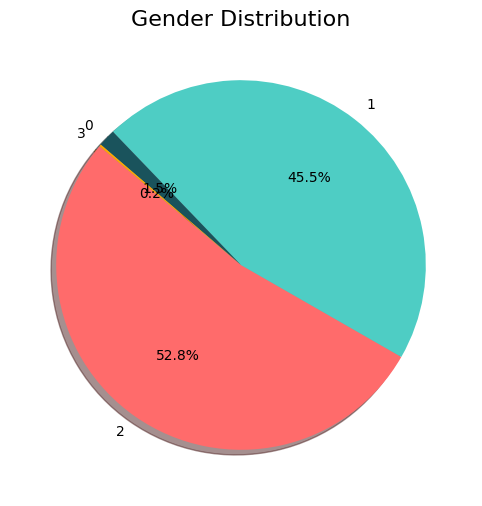

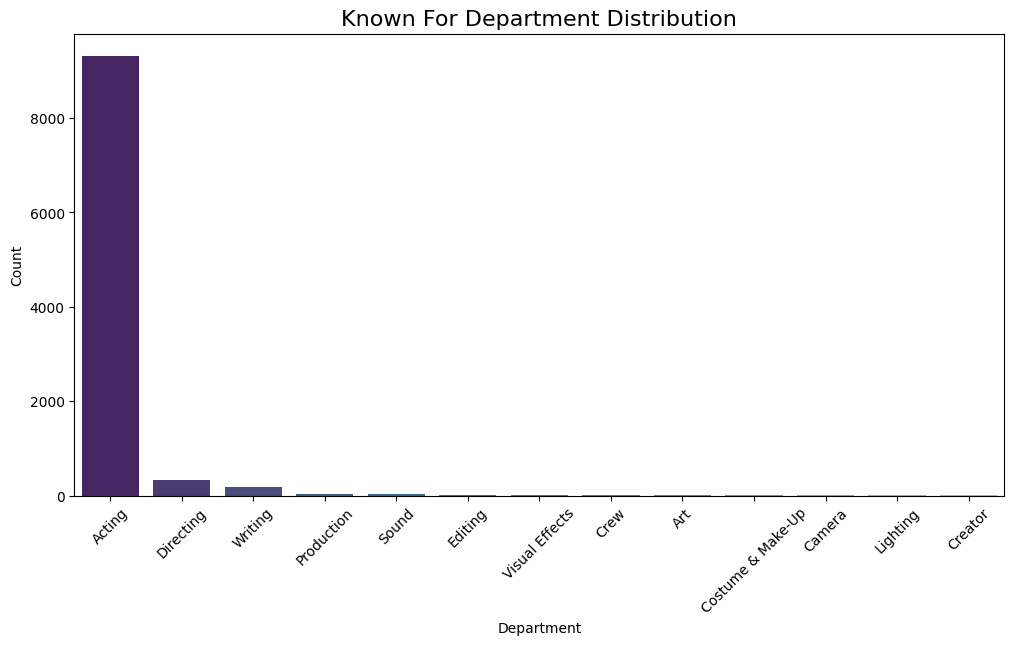

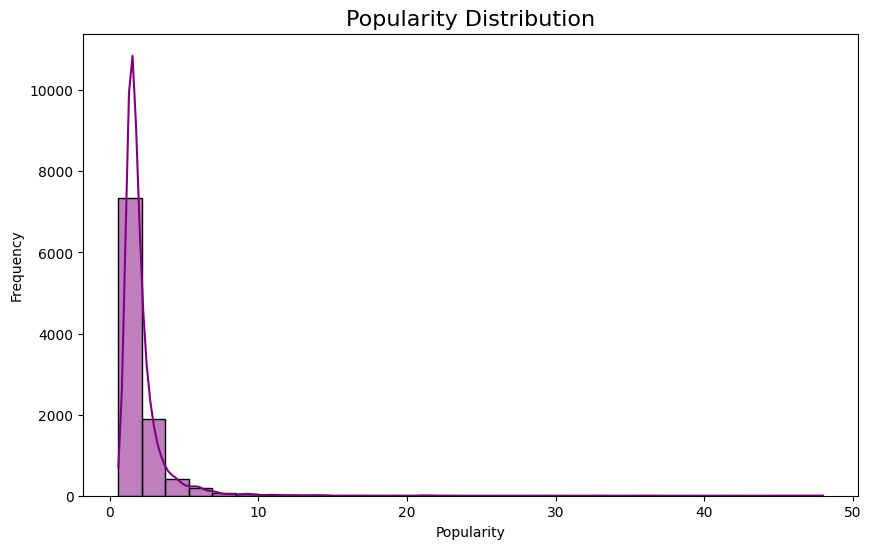

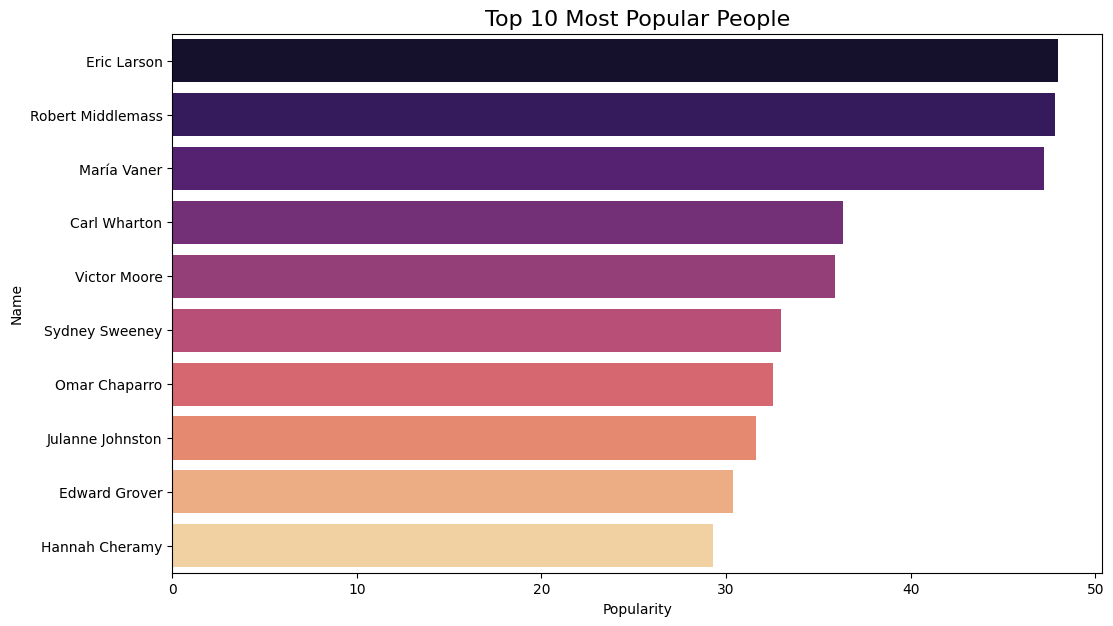

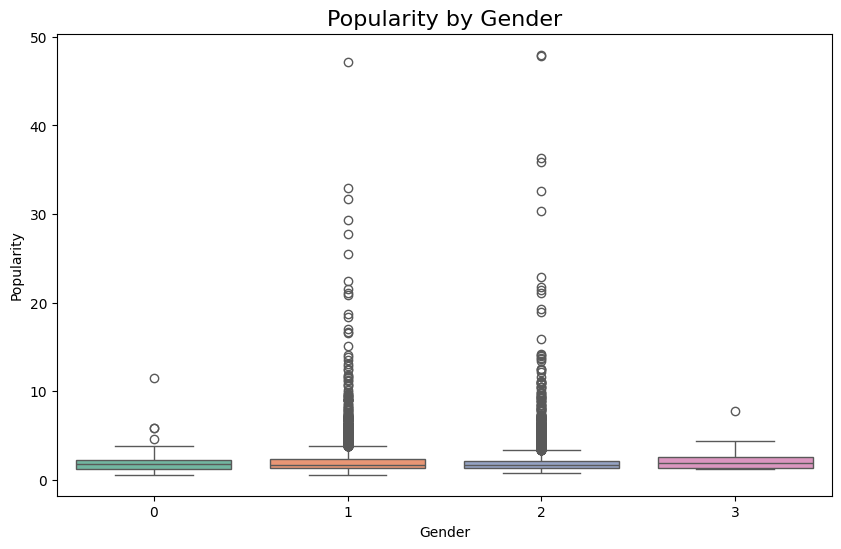

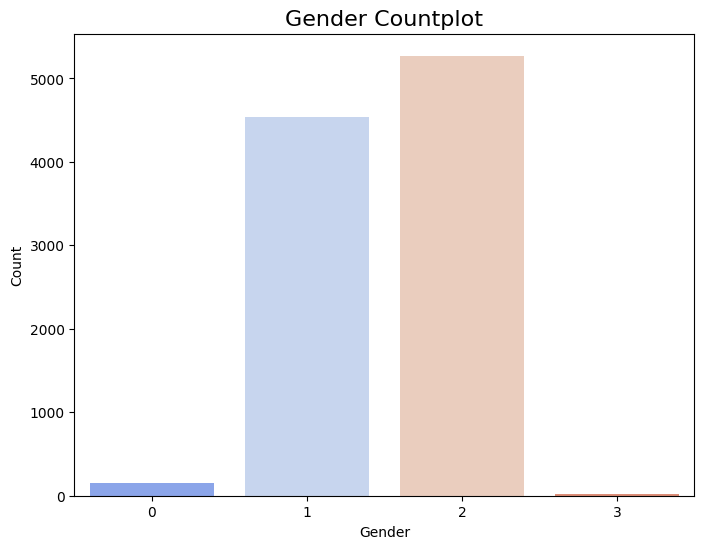

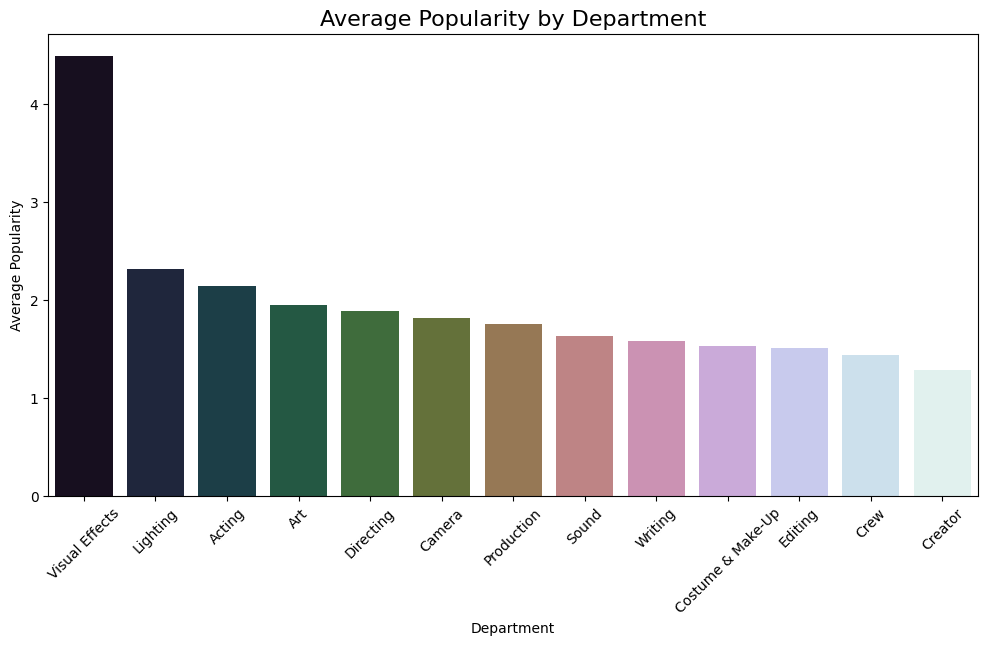

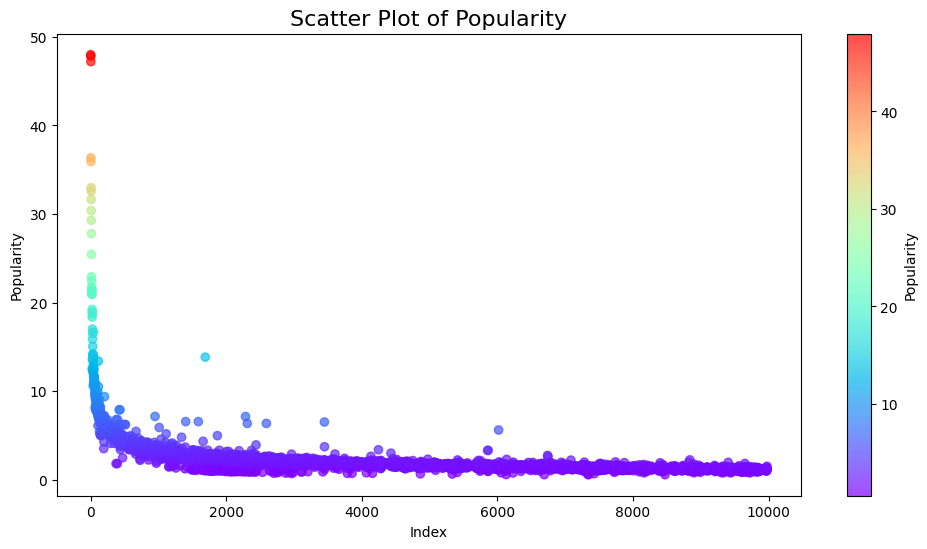

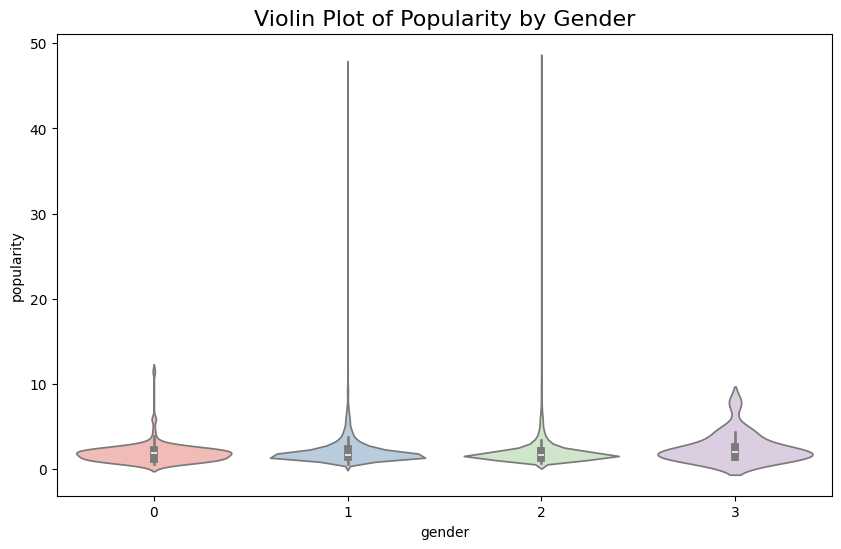

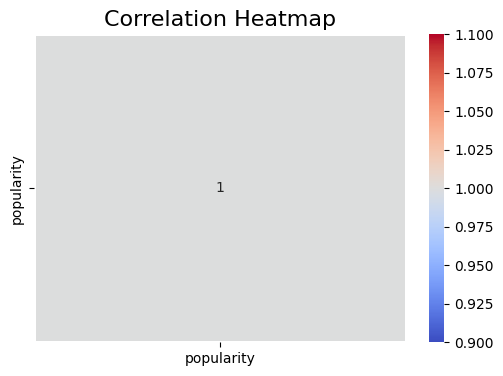

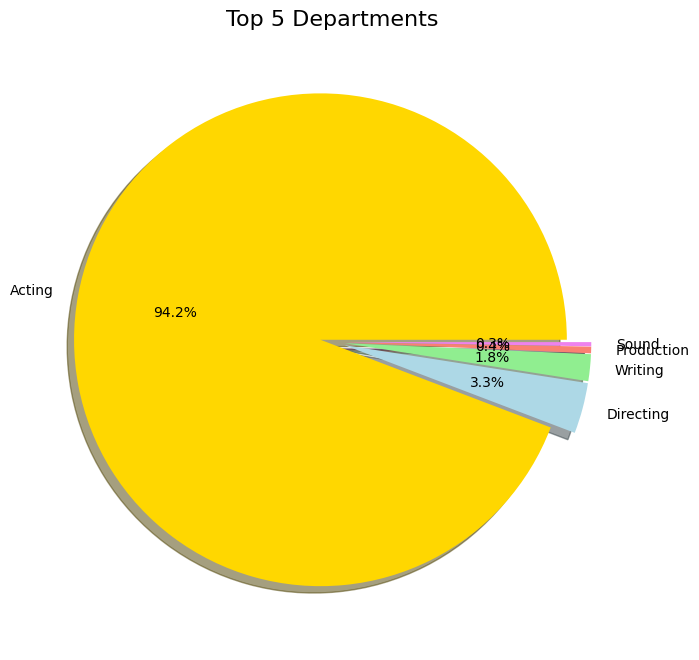

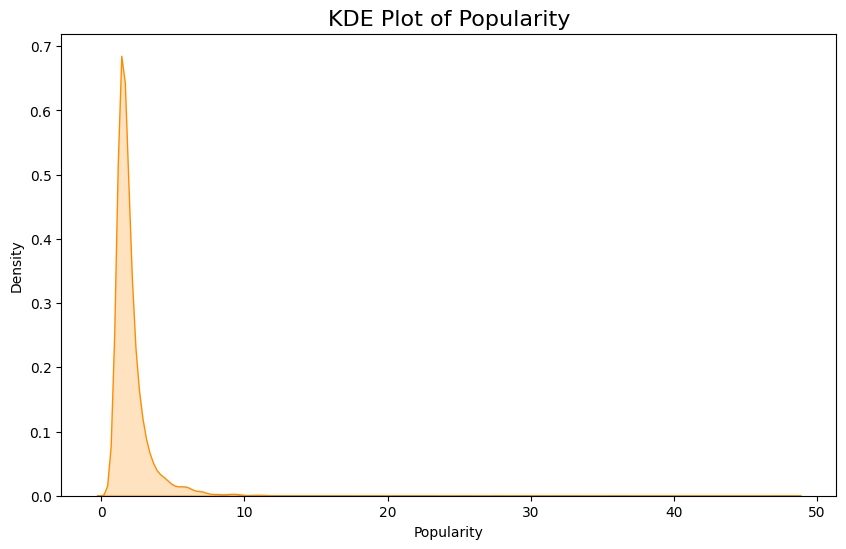

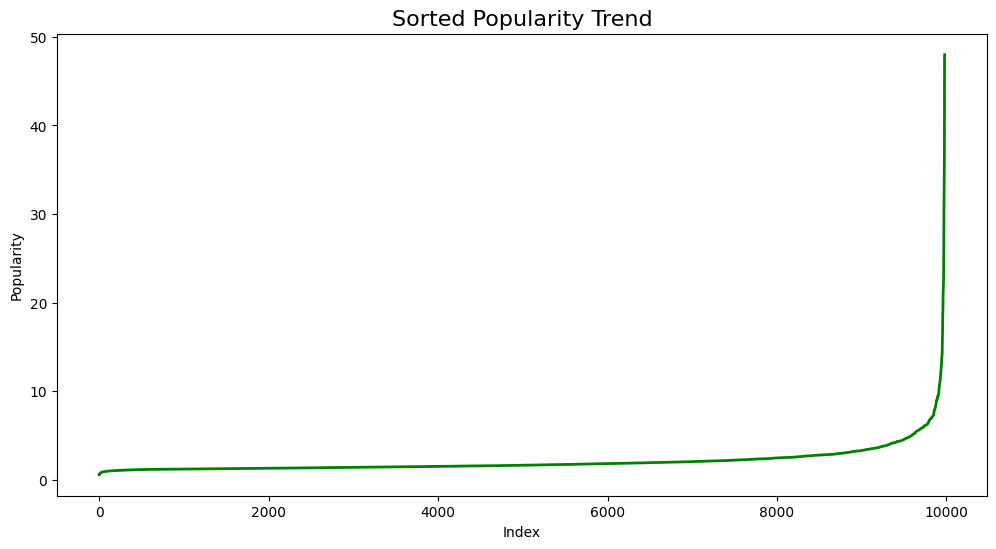


Top 10 Most Popular People:
                name  gender known_for_department  popularity
0        Eric Larson       2       Visual Effects     47.9780
1  Robert Middlemass       2               Acting     47.8017
2        María Vaner       1               Acting     47.2016
3       Carl Wharton       2               Acting     36.3365
4       Victor Moore       2               Acting     35.9181
5     Sydney Sweeney       1               Acting     32.9698
6      Omar Chaparro       2               Acting     32.5659
7   Julanne Johnston       1               Acting     31.6448
8      Edward Grover       2               Acting     30.3934
9     Hannah Cheramy       1               Acting     29.2875


In [14]:
# ===================================================
# 1. GENDER DISTRIBUTION
# ===================================================
plt.figure(figsize=(8,6))

gender_counts = df['gender'].value_counts()

colors = ['#ff6b6b', '#4ecdc4', '#1a535c', '#ffa600']

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    shadow=True
)

plt.title("Gender Distribution", fontsize=16)
plt.show()

# ===================================================
# 2. KNOWN FOR DEPARTMENT COUNT
# ===================================================
plt.figure(figsize=(12,6))

department_counts = df['known_for_department'].value_counts()

sns.barplot(
    x=department_counts.index,
    y=department_counts.values,
    palette='viridis'
)

plt.title("Known For Department Distribution", fontsize=16)
plt.xlabel("Department")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# ===================================================
# 3. POPULARITY DISTRIBUTION
# ===================================================
plt.figure(figsize=(10,6))

sns.histplot(
    df['popularity'],
    bins=30,
    kde=True,
    color='purple'
)

plt.title("Popularity Distribution", fontsize=16)
plt.xlabel("Popularity")
plt.ylabel("Frequency")
plt.show()

# ===================================================
# 4. TOP 10 MOST POPULAR PEOPLE
# ===================================================
top10 = df.sort_values(by='popularity', ascending=False).head(10)

plt.figure(figsize=(12,7))

sns.barplot(
    x='popularity',
    y='name',
    data=top10,
    palette='magma'
)

plt.title("Top 10 Most Popular People", fontsize=16)
plt.xlabel("Popularity")
plt.ylabel("Name")
plt.show()

# ===================================================
# 5. BOXPLOT OF POPULARITY BY GENDER
# ===================================================
plt.figure(figsize=(10,6))

sns.boxplot(
    x='gender',
    y='popularity',
    data=df,
    palette='Set2'
)

plt.title("Popularity by Gender", fontsize=16)
plt.xlabel("Gender")
plt.ylabel("Popularity")
plt.show()

# ===================================================
# 6. COUNTPLOT OF GENDER
# ===================================================
plt.figure(figsize=(8,6))

sns.countplot(
    x='gender',
    data=df,
    palette='coolwarm'
)

plt.title("Gender Countplot", fontsize=16)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# ===================================================
# 7. DEPARTMENT VS AVERAGE POPULARITY
# ===================================================
avg_popularity = df.groupby('known_for_department')['popularity'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    x=avg_popularity.index,
    y=avg_popularity.values,
    palette='cubehelix'
)

plt.title("Average Popularity by Department", fontsize=16)
plt.xlabel("Department")
plt.ylabel("Average Popularity")
plt.xticks(rotation=45)
plt.show()

# ===================================================
# 8. SCATTER PLOT - INDEX VS POPULARITY
# ===================================================
plt.figure(figsize=(12,6))

plt.scatter(
    range(len(df)),
    df['popularity'],
    c=df['popularity'],
    cmap='rainbow',
    alpha=0.7
)

plt.colorbar(label='Popularity')
plt.title("Scatter Plot of Popularity", fontsize=16)
plt.xlabel("Index")
plt.ylabel("Popularity")
plt.show()

# ===================================================
# 9. VIOLIN PLOT
# ===================================================
plt.figure(figsize=(10,6))

sns.violinplot(
    x='gender',
    y='popularity',
    data=df,
    palette='Pastel1'
)

plt.title("Violin Plot of Popularity by Gender", fontsize=16)
plt.show()

# ===================================================
# 10. HEATMAP OF NUMERICAL FEATURES
# ===================================================
plt.figure(figsize=(6,4))

numeric_df = df[['popularity']]

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=2
)

plt.title("Correlation Heatmap", fontsize=16)
plt.show()

# ===================================================
# 11. TOP DEPARTMENTS PIE CHART
# ===================================================
top_departments = df['known_for_department'].value_counts().head(5)

plt.figure(figsize=(8,8))

colors = ['gold', 'lightblue', 'lightgreen', 'salmon', 'violet']

plt.pie(
    top_departments,
    labels=top_departments.index,
    autopct='%1.1f%%',
    colors=colors,
    shadow=True,
    explode=[0.05]*5
)

plt.title("Top 5 Departments", fontsize=16)
plt.show()

# ===================================================
# 12. KDE PLOT OF POPULARITY
# ===================================================
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df['popularity'],
    fill=True,
    color='darkorange'
)

plt.title("KDE Plot of Popularity", fontsize=16)
plt.xlabel("Popularity")
plt.show()

# ===================================================
# 13. LINE PLOT OF SORTED POPULARITY
# ===================================================
sorted_popularity = df['popularity'].sort_values().reset_index(drop=True)

plt.figure(figsize=(12,6))

plt.plot(
    sorted_popularity,
    color='green',
    linewidth=2
)

plt.title("Sorted Popularity Trend", fontsize=16)
plt.xlabel("Index")
plt.ylabel("Popularity")
plt.show()

# ===================================================
# 14. DISPLAY TOP 10 RECORDS
# ===================================================
print("\nTop 10 Most Popular People:")
print(top10[['name', 'gender', 'known_for_department', 'popularity']])


## Feature engineering


DATASET INFORMATION

First 5 Rows:
                name  gender known_for_department      original_name  \
0        Eric Larson       2       Visual Effects        Eric Larson   
1  Robert Middlemass       2               Acting  Robert Middlemass   
2        María Vaner       1               Acting        María Vaner   
3       Carl Wharton       2               Acting       Carl Wharton   
4       Victor Moore       2               Acting       Victor Moore   

   popularity  
0     47.9780  
1     47.8017  
2     47.2016  
3     36.3365  
4     35.9181  

Dataset Shape:
(9980, 5)

Columns:
Index(['name', 'gender', 'known_for_department', 'original_name',
       'popularity'],
      dtype='object')

Missing Values:
name                    0
gender                  0
known_for_department    5
original_name           0
popularity              0
dtype: int64

Target Classes:
['Acting' 'Art' 'Camera' 'Costume & Make-Up' 'Creator' 'Crew' 'Directing'
 'Editing' 'Lighting' 'Production' 'Sou

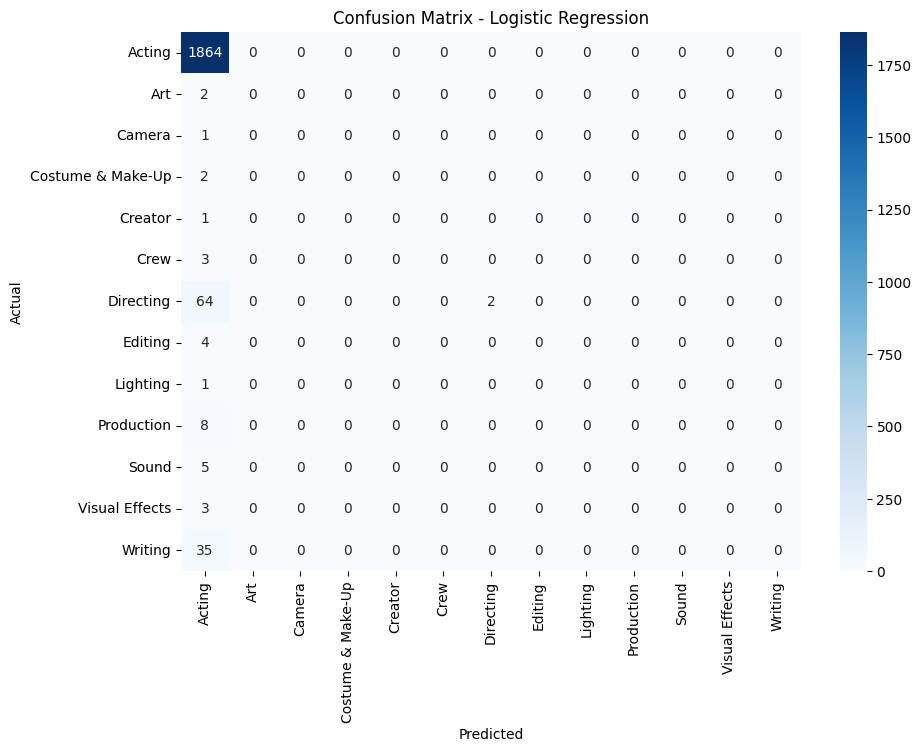

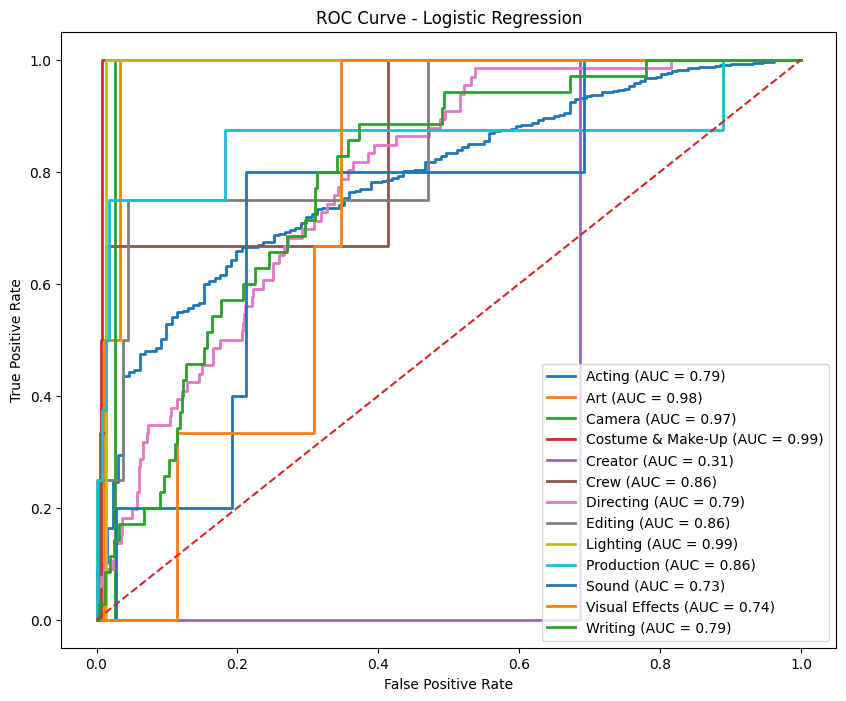



MODEL: Random Forest

Accuracy: 0.9248

Classification Report:

                   precision    recall  f1-score   support

           Acting       0.96      0.96      0.96      1864
              Art       0.00      0.00      0.00         2
           Camera       1.00      1.00      1.00         1
Costume & Make-Up       0.50      1.00      0.67         2
          Creator       0.00      0.00      0.00         1
             Crew       0.25      0.33      0.29         3
        Directing       0.43      0.35      0.38        66
          Editing       0.50      0.50      0.50         4
         Lighting       0.00      0.00      0.00         1
       Production       0.36      0.62      0.45         8
            Sound       0.75      0.60      0.67         5
   Visual Effects       0.00      0.00      0.00         3
          Writing       0.35      0.37      0.36        35

         accuracy                           0.92      1995
        macro avg       0.39      0.44      0.4

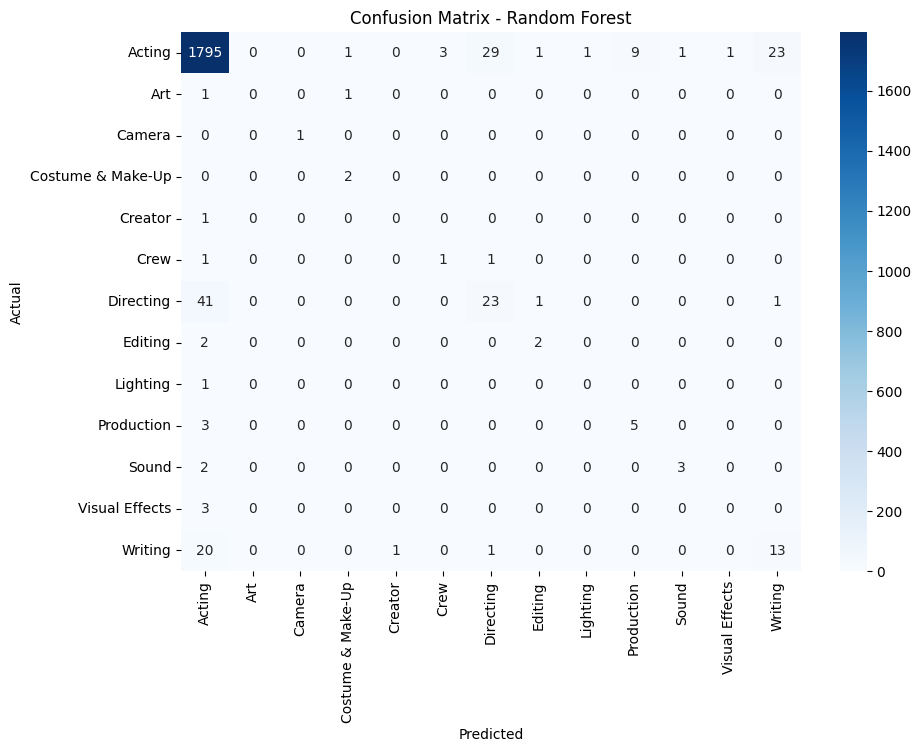

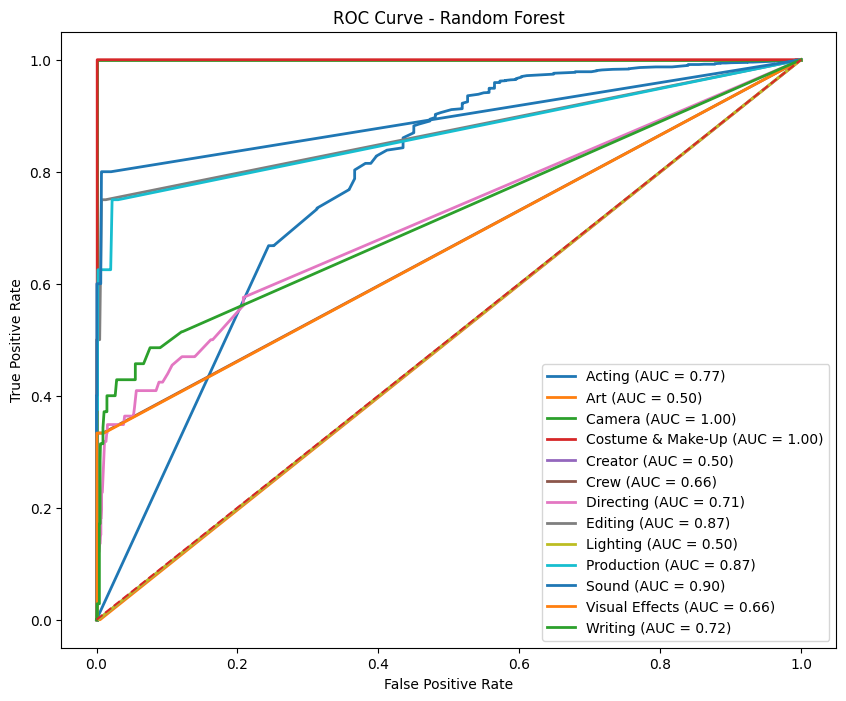



MODEL: Naive Bayes

Accuracy: 0.9358

Classification Report:

                   precision    recall  f1-score   support

           Acting       0.94      1.00      0.97      1864
              Art       0.00      0.00      0.00         2
           Camera       0.00      0.00      0.00         1
Costume & Make-Up       0.00      0.00      0.00         2
          Creator       0.00      0.00      0.00         1
             Crew       0.00      0.00      0.00         3
        Directing       1.00      0.05      0.09        66
          Editing       0.00      0.00      0.00         4
         Lighting       0.00      0.00      0.00         1
       Production       0.00      0.00      0.00         8
            Sound       0.00      0.00      0.00         5
   Visual Effects       0.00      0.00      0.00         3
          Writing       0.00      0.00      0.00        35

         accuracy                           0.94      1995
        macro avg       0.15      0.08      0.08 

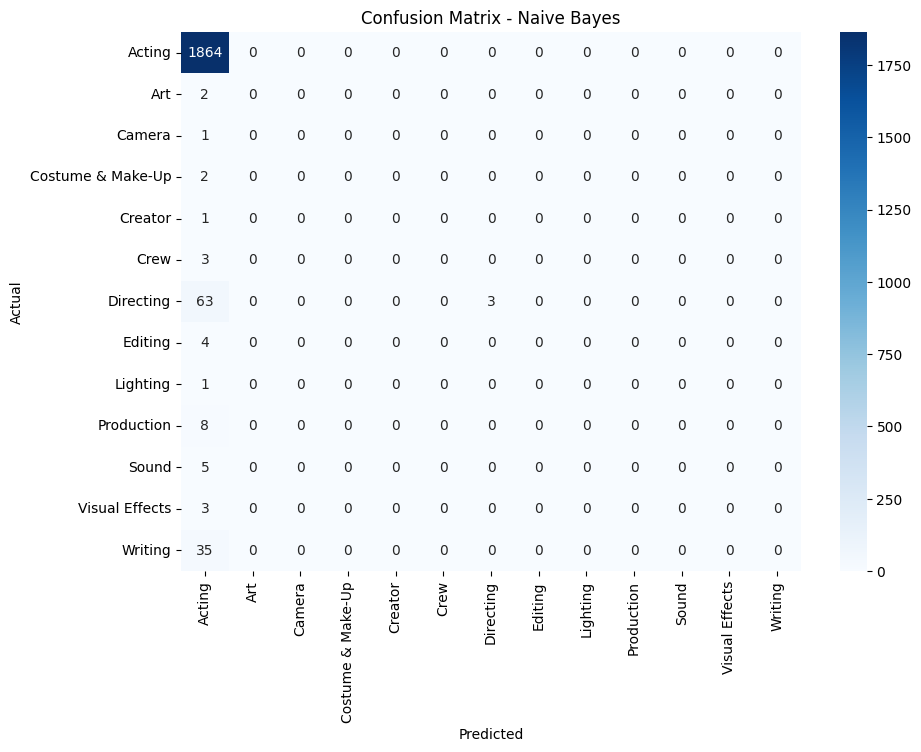

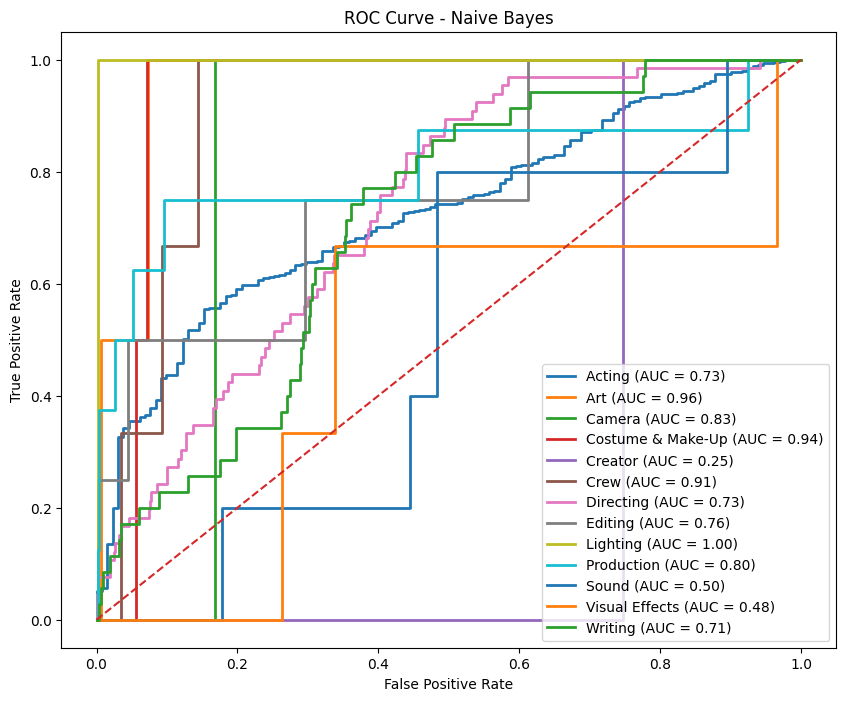



MODEL: SVM

Accuracy: 0.9343

Classification Report:

                   precision    recall  f1-score   support

           Acting       0.93      1.00      0.97      1864
              Art       0.00      0.00      0.00         2
           Camera       0.00      0.00      0.00         1
Costume & Make-Up       0.00      0.00      0.00         2
          Creator       0.00      0.00      0.00         1
             Crew       0.00      0.00      0.00         3
        Directing       0.00      0.00      0.00        66
          Editing       0.00      0.00      0.00         4
         Lighting       0.00      0.00      0.00         1
       Production       0.00      0.00      0.00         8
            Sound       0.00      0.00      0.00         5
   Visual Effects       0.00      0.00      0.00         3
          Writing       0.00      0.00      0.00        35

         accuracy                           0.93      1995
        macro avg       0.07      0.08      0.07      199

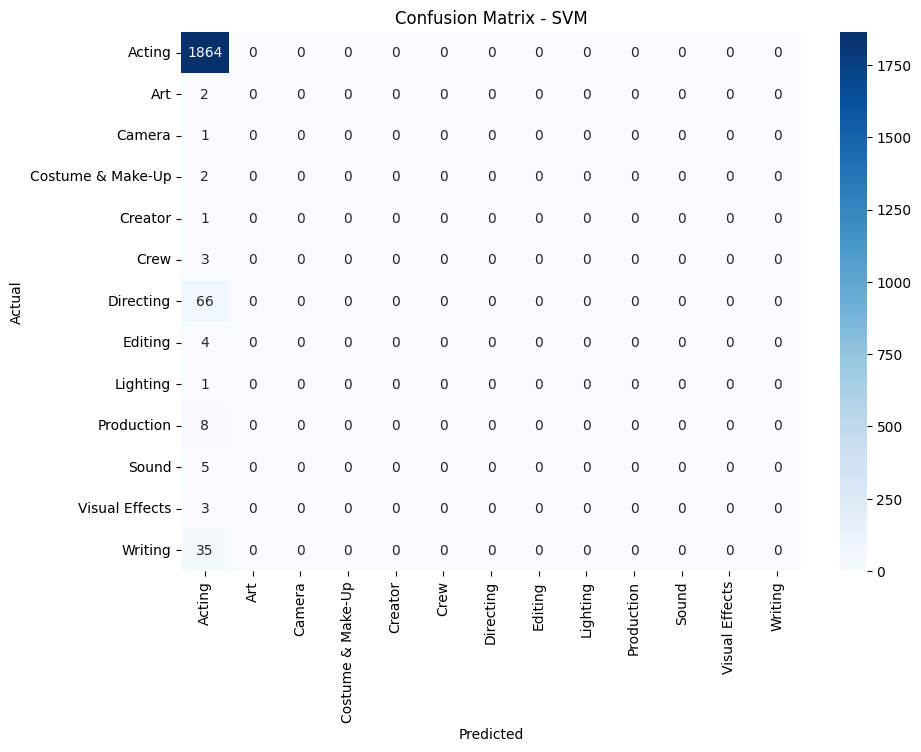

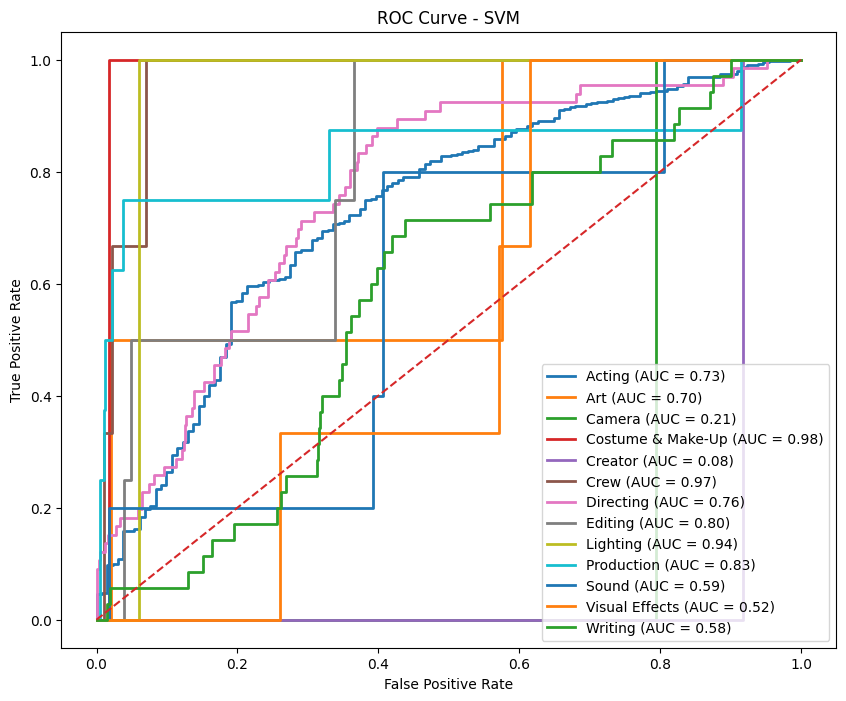



FINAL MODEL COMPARISON
                 Model  Accuracy
2          Naive Bayes  0.935840
0  Logistic Regression  0.935338
3                  SVM  0.934336
1        Random Forest  0.924812


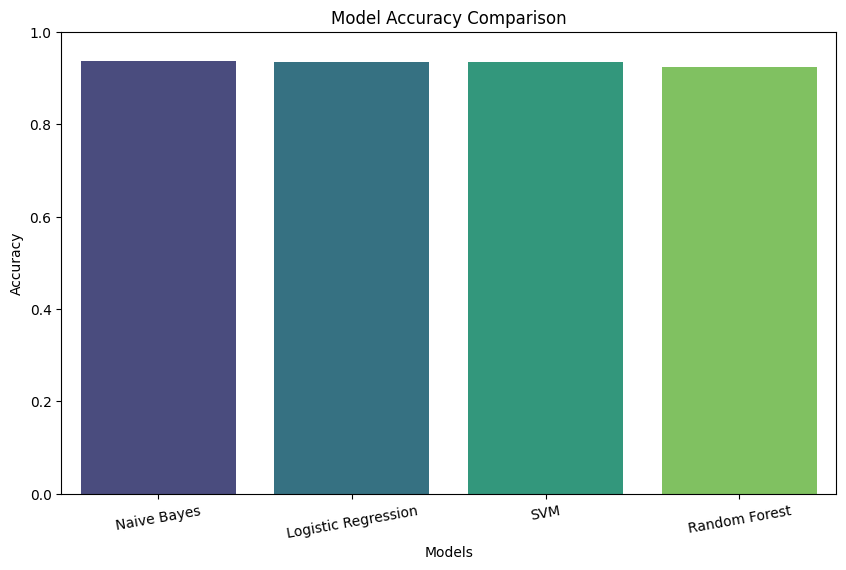


Best Model:
Model       Naive Bayes
Accuracy        0.93584
Name: 2, dtype: object

Machine Learning Pipeline Completed Successfully!


In [15]:
# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

# ROC Support
from sklearn.preprocessing import label_binarize



print("="*60)
print("DATASET INFORMATION")
print("="*60)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

# ============================================================
# KEEP REQUIRED COLUMNS
# ============================================================

df = df[[
    'name',
    'gender',
    'known_for_department',
    'original_name',
    'popularity'
]]

# ============================================================
# HANDLE MISSING VALUES
# ============================================================

df['name'] = df['name'].fillna("Unknown")

df['original_name'] = df['original_name'].fillna("Unknown")

df['gender'] = df['gender'].fillna("Unknown")

# Remove rows where target is missing
df = df.dropna(subset=['known_for_department'])

# ============================================================
# ENSURE POPULARITY IS POSITIVE
# ============================================================

df['popularity'] = df['popularity'].abs()

# ============================================================
# FEATURES AND TARGET
# ============================================================

X = df.drop('known_for_department', axis=1)

y = df['known_for_department']

# ============================================================
# LABEL ENCODING TARGET
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("\nTarget Classes:")
print(label_encoder.classes_)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================
# IMPORTANT:
# Split BEFORE preprocessing
# To avoid DATA LEAKAGE
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# ============================================================
# FEATURE TYPES
# ============================================================

text_features = ['name', 'original_name']

categorical_features = ['gender']

numerical_features = ['popularity']

# ============================================================
# COLUMN TRANSFORMER
# ============================================================

preprocessor = ColumnTransformer(

    transformers=[

        # ====================================================
        # TF-IDF FOR NAME
        # ====================================================

        (
            'name_tfidf',
            TfidfVectorizer(max_features=500),
            'name'
        ),

        # ====================================================
        # TF-IDF FOR ORIGINAL NAME
        # ====================================================

        (
            'original_name_tfidf',
            TfidfVectorizer(max_features=500),
            'original_name'
        ),

        # ====================================================
        # ONE HOT ENCODING
        # ====================================================

        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        ),

        # ====================================================
        # NUMERICAL FEATURES
        # ====================================================

        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median'))
            ]),
            numerical_features
        )

    ],

    remainder='drop'
)

# ============================================================
# MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=500
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "Naive Bayes":
        MultinomialNB(),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        )
}

# ============================================================
# STORE RESULTS
# ============================================================

results = []

# ============================================================
# TRAINING LOOP
# ============================================================

for model_name, model in models.items():

    print("\n")
    print("="*70)
    print(f"MODEL: {model_name}")
    print("="*70)

    # ========================================================
    # CREATE PIPELINE
    # ========================================================

    pipeline = Pipeline([

        ('preprocessor', preprocessor),

        ('classifier', model)

    ])

    # ========================================================
    # TRAIN MODEL
    # ========================================================

    pipeline.fit(X_train, y_train)

    # ========================================================
    # PREDICTIONS
    # ========================================================

    y_pred = pipeline.predict(X_test)

    # ========================================================
    # ACCURACY
    # ========================================================

    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nAccuracy: {accuracy:.4f}")

    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    print("\nClassification Report:\n")

    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    ))

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10,7))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )

    plt.title(f'Confusion Matrix - {model_name}')

    plt.xlabel('Predicted')

    plt.ylabel('Actual')

    plt.show()

    # ========================================================
    # ROC CURVE
    # ========================================================

    y_prob = pipeline.predict_proba(X_test)

    # Convert multiclass labels into binary format
    y_test_bin = label_binarize(
        y_test,
        classes=np.unique(y_test)
    )

    n_classes = y_test_bin.shape[1]

    plt.figure(figsize=(10,8))

    for i in range(n_classes):

        fpr, tpr, thresholds = roc_curve(
            y_test_bin[:, i],
            y_prob[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            lw=2,
            label=f'{label_encoder.classes_[i]} (AUC = {roc_auc:.2f})'
        )

    # Random Line
    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel('False Positive Rate')

    plt.ylabel('True Positive Rate')

    plt.title(f'ROC Curve - {model_name}')

    plt.legend(loc='lower right')

    plt.show()

    # ========================================================
    # STORE RESULTS
    # ========================================================

    results.append({
        "Model": model_name,
        "Accuracy": accuracy
    })

# ============================================================
# RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(results)

# ============================================================
# SORT RESULTS
# ============================================================

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

# ============================================================
# FINAL RESULTS
# ============================================================

print("\n")
print("="*70)
print("FINAL MODEL COMPARISON")
print("="*70)

print(results_df)

# ============================================================
# VISUALIZE MODEL ACCURACY
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results_df,
    palette='viridis'
)

plt.title('Model Accuracy Comparison')

plt.ylabel('Accuracy')

plt.xlabel('Models')

plt.ylim(0, 1)

plt.xticks(rotation=10)

plt.show()

# ============================================================
# BEST MODEL
# ============================================================

best_model = results_df.iloc[0]

print("\nBest Model:")
print(best_model)

# ============================================================
# END
# ============================================================

print("\nMachine Learning Pipeline Completed Successfully!")

## Thank you...pls upvote!!!!!!